In [2]:
#20:45 21:14 21:20
#1.	Napraviti podskup podataka koji ne sadrži automobile čiji broj prijeđenih kilometara (Kilometer) prelazi 200.000.
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("../docs/oldDocs/cars.csv", na_values=['', ' ', '/', '-', 'Na'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1800 non-null   object 
 1   Model               1800 non-null   object 
 2   Price               1800 non-null   int64  
 3   Year                1797 non-null   float64
 4   Kilometer           1800 non-null   int64  
 5   Engine              1800 non-null   int64  
 6   Max.Power           1800 non-null   int64  
 7   Max.Torque          1800 non-null   int64  
 8   Length              1798 non-null   float64
 9   Width               1800 non-null   int64  
 10  Seating.Capacity    1800 non-null   int64  
 11  Fuel.Tank.Capacity  1800 non-null   float64
dtypes: float64(3), int64(7), object(2)
memory usage: 168.9+ KB


In [5]:
df.isna().sum()
#Year i Length imaju NA vrednosti

Make                  0
Model                 0
Price                 0
Year                  3
Kilometer             0
Engine                0
Max.Power             0
Max.Torque            0
Length                2
Width                 0
Seating.Capacity      0
Fuel.Tank.Capacity    0
dtype: int64

In [6]:
df=df[df['Kilometer']<200000]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1794 entries, 0 to 1799
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1794 non-null   object 
 1   Model               1794 non-null   object 
 2   Price               1794 non-null   int64  
 3   Year                1791 non-null   float64
 4   Kilometer           1794 non-null   int64  
 5   Engine              1794 non-null   int64  
 6   Max.Power           1794 non-null   int64  
 7   Max.Torque          1794 non-null   int64  
 8   Length              1792 non-null   float64
 9   Width               1794 non-null   int64  
 10  Seating.Capacity    1794 non-null   int64  
 11  Fuel.Tank.Capacity  1794 non-null   float64
dtypes: float64(3), int64(7), object(2)
memory usage: 182.2+ KB


In [8]:
from scipy.stats import shapiro

stats,p=shapiro(df['Year'].dropna())
if p < 0.05:
    print("Kolona year nema normalnu raspodelu")
else:
    print("Kolona year ima normalnu raspodelu")

Kolona year nema normalnu raspodelu


In [9]:
from scipy.stats import shapiro

stats,p=shapiro(df['Length'].dropna())
if p < 0.05:
    print("Kolona Length nema normalnu raspodelu")
else:
    print("Kolona Length ima normalnu raspodelu")

Kolona Length nema normalnu raspodelu


In [10]:
#obe kolone nemaju normaln uraspodelu znaci menjamo vrednosti sa medijanom
df['Length']=df['Length'].fillna(df['Length'].median())

In [11]:
#obe kolone nemaju normaln uraspodelu znaci menjamo vrednosti sa mdeijanom
df['Year']=df['Year'].fillna(df['Year'].median())

In [12]:
df.isna().sum() # nijedna kolona nema NA vise

Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Engine                0
Max.Power             0
Max.Torque            0
Length                0
Width                 0
Seating.Capacity      0
Fuel.Tank.Capacity    0
dtype: int64

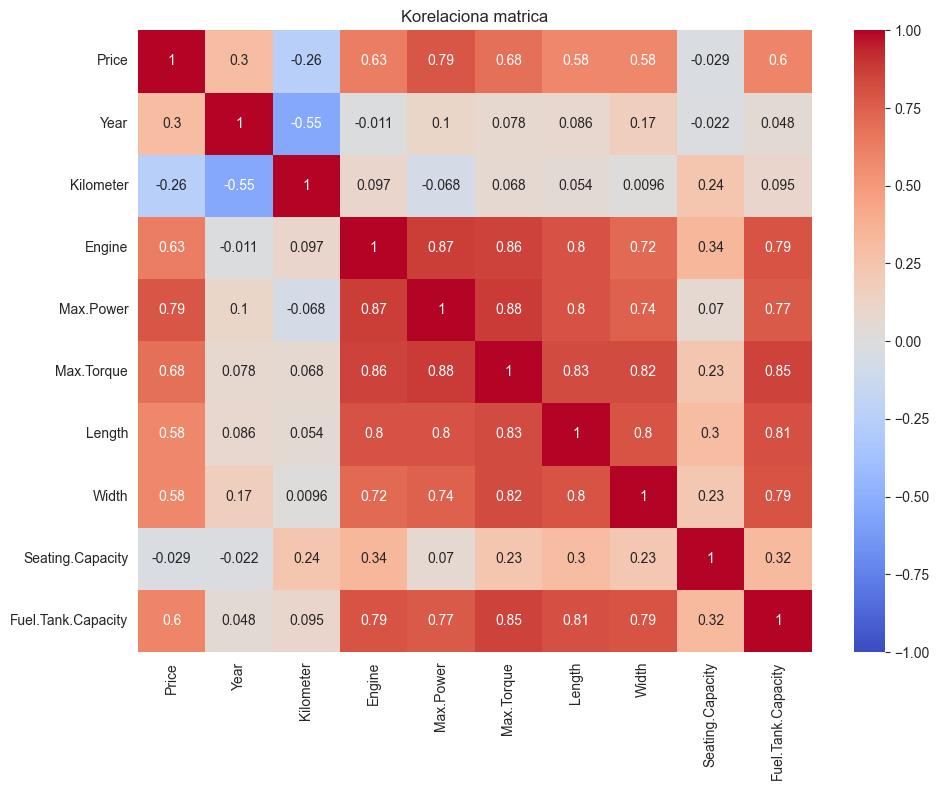

In [13]:
import matplotlib.pyplot as plt
import seaborn as sb

corr_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(numeric_only=True), annot=True,
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelaciona matrica")
plt.tight_layout()
plt.show()

In [14]:
#na osnovu prikaza matrice korelacije za kolonu Price:  i za njeno predvidajneje
# potrebno je ukljuciti Max.Power sa korealcijom 0.79 vidimo da sto vise raste max power veca je cena logicni sportski automobili bolji motor skuplji auto
# max.Torgue kako raste ova kolona rste i cena ... max broj obrtaja
# Zapremina motora sa 0.63 poz korelacijom isto ima efekata na cenu
# FuelTank capictiy takodje ima veliku bitnost za veliku cenu 0.6 korelacija
#zato biram ove 4 kolone kao najbitnije u modelu

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1794 entries, 0 to 1799
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1794 non-null   object 
 1   Model               1794 non-null   object 
 2   Price               1794 non-null   int64  
 3   Year                1794 non-null   float64
 4   Kilometer           1794 non-null   int64  
 5   Engine              1794 non-null   int64  
 6   Max.Power           1794 non-null   int64  
 7   Max.Torque          1794 non-null   int64  
 8   Length              1794 non-null   float64
 9   Width               1794 non-null   int64  
 10  Seating.Capacity    1794 non-null   int64  
 11  Fuel.Tank.Capacity  1794 non-null   float64
dtypes: float64(3), int64(7), object(2)
memory usage: 182.2+ KB


In [16]:
target=['Price']
features=['Max.Power','Max.Torque ','Engine','Fuel.Tank.Capacity']

In [17]:
df['Make'].value_counts() # vidimo da marka automobila je nomilanlna i verovatno ne doprinisumodelu

Make
Maruti Suzuki    384
Hyundai          318
Mercedes-Benz    145
Honda            134
Audi             117
Toyota           113
Mahindra         106
BMW               87
Tata              46
Ford              46
Volkswagen        41
Renault           41
Skoda             37
Land Rover        30
Kia               23
Jeep              16
Volvo             16
Nissan            15
MG                13
Jaguar            13
Porsche           12
MINI               9
Datsun             8
Lexus              5
Chevrolet          4
Mitsubishi         4
Rolls-Royce        3
Ssangyong          3
Isuzu              2
Maserati           1
Ferrari            1
Fiat               1
Name: count, dtype: int64

In [18]:
df.drop(columns='Make',inplace=True)

In [19]:
df['Model'].value_counts()# ista stvar i za model auta

Model
X1 sDrive20d xLine                    15
Swift DZire VDI                       14
Fortuner 2.8 4x2 AT [2016-2020]       13
City V                                13
Swift DZire VXI                       12
                                      ..
Compass Limited (O) 1.4 Petrol DCT     1
Ciaz Alpha 1.4 AT                      1
City 1.5 E MT                          1
Alto 800 Std                           1
GLA 200 d Style                        1
Name: count, Length: 916, dtype: int64

In [20]:
df.drop(columns='Model',inplace=True)

In [21]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df,test_size=0.2, random_state=42)

In [22]:
import statsmodels.formula.api as smf
lm1=smf.ols('Price~ Q("Max.Power") + Q("Max.Torque") + Engine + Q("Fuel.Tank.Capacity") ',data=df_train)
lm1=lm1.fit()

In [23]:
lm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     588.3
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          3.60e-300
Time:                        17:14:52   Log-Likelihood:                -22393.
No. Observations:                1435   AIC:                         4.480e+04
Df Residuals:                    1430   BIC:                         4.482e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -1.908e+06   1.74e+05    -10.995      0.000   -2.25e+06   -1.57e+06
Q("Max.Power")           3.574e+04   1549.238     23.069      0.000    3.27e+04    3.88e+04
Q("Max.Torque")           279.2527    762.488      0.366      0.714   -1216.463    1774.968
Engine                  -1033.3117    138.786     -7.445      0.000   -1305.557    -761.066
Q("Fuel.Tank.Capacity")    1.4e+04   5096.096      2.748      0.006    4005.747     2.4e+04
==============================================================================
Omnibus:                     1574.496   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           248452.041
Skew:                           5.104   Prob(JB):                         0.00
Kurtosis:                      66.648   Cond. No.                     8.17e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.17e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
#nakon summary vidimo jednu jako bitnu stavr prvo condition number je veliki to znaci da postoji multikolinearnost i da nam nesto nije bitno u modelu to je ova kolona Max.Torque jer je njeno p=0.714 a trebalo bi da bude manje od 0.05. sve ostale kolone su odlicne i bitne za model ali ovo je lose ...

In [25]:
import statsmodels.formula.api as smf # izbacujemo u novom modelu ovu torque kolonu
lm2=smf.ols('Price~ Q("Max.Power") + Engine + Q("Fuel.Tank.Capacity") ',data=df_train)
lm2=lm2.fit()

In [38]:
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     784.8
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          1.26e-301
Time:                        17:15:12   Log-Likelihood:                -22393.
No. Observations:                1435   AIC:                         4.479e+04
Df Residuals:                    1431   BIC:                         4.482e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -1

In [27]:
# gledajmo Fstatistiku na sonovu summaryija .. 784 je odlicna vrednost
# p vrednosti kolona  su oovm modelu odlicne sve su ispod granice <0.05 a F statistica je veca nego u prethodnom
# onda imamo R2=0.622 koje znaci da objasvanjamo 62% modela ... tako nesto ovo ne znam
print(lm2.resid.describe().round(2))

count        1435.00
mean           -0.00
std       1449177.82
min      -8928927.56
25%       -592452.51
50%         55151.11
75%        416725.13
max      22146151.97
dtype: float64


In [28]:
# vidimo preko reziduala koji zapravo pokazuju razliku izmedju stvarne vrednosti i obzervacije koju je nas model predvideo
# da

In [66]:
df_train['fittedvalues']=lm2.fittedvalues.round(1)

In [67]:
df_train

,Price,Year,Kilometer,Engine,Max.Power,Max.Torque,Length,Width,Seating.Capacity,Fuel.Tank.Capacity,fittedvalues
1026,3400000,2018.0,51000,1968,190,400,4933.0,1874,5,75.0,4008939.7
1736,350000,2012.0,130000,1598,105,250,4386.0,1699,5,55.0,1026944.7
1558,8500000,2021.0,32500,1969,232,480,4953.0,2008,7,71.0,5461346.1
1644,409999,2021.0,13424,796,47,69,3445.0,1515,5,35.0,-540937.3
176,2682000,2015.0,76345,2997,254,619,4804.0,2141,5,70.0,5188494.8
...,...,...,...,...,...,...,...,...,...,...,...
1133,27500000,2020.0,11000,2993,244,600,5199.0,2220,4,105.0,5353848.0
1297,490000,2017.0,82000,1197,83,115,3995.0,1745,5,37.0,375972.8
862,695000,2017.0,51292,1497,117,145,4440.0,1695,5,40.0,1338943.8
1463,4200000,2018.0,102000,2143,201,500,4819.0,2141,5,93.0,4494586.3


In [73]:
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

help(precision_recall_fscore_support)

Help on function precision_recall_fscore_support in module sklearn.metrics._classification:

precision_recall_fscore_support(
    y_true,
    y_pred,
    *,
    beta=1.0,
    labels=None,
    pos_label=1,
    average=None,
    warn_for=('precision', 'recall', 'f-score'),
    sample_weight=None,
    zero_division='warn'
)
    Compute precision, recall, F-measure and support for each class.

    The precision is the ratio ``tp / (tp + fp)`` where ``tp`` is the number of
    true positives and ``fp`` the number of false positives. The precision is
    intuitively the ability of the classifier not to label a negative sample as
    positive.

    The recall is the ratio ``tp / (tp + fn)`` where ``tp`` is the number of
    true positives and ``fn`` the number of false negatives. The recall is
    intuitively the ability of the classifier to find all the positive samples.

    The F-beta score can be interpreted as a weighted harmonic mean of
    the precision and recall, where an F-beta scor

In [53]:

lm2.fittedvalues.round(2).count()

np.int64(1435)

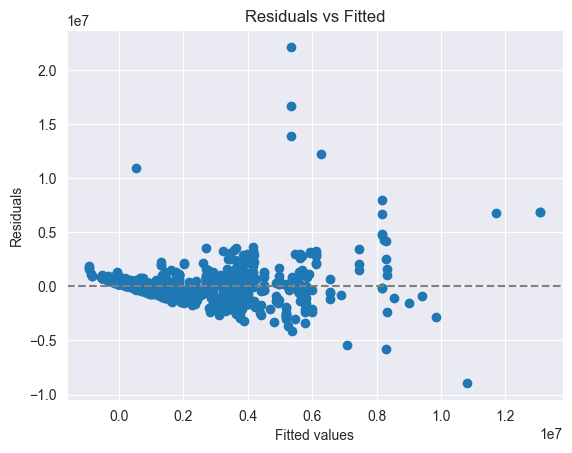

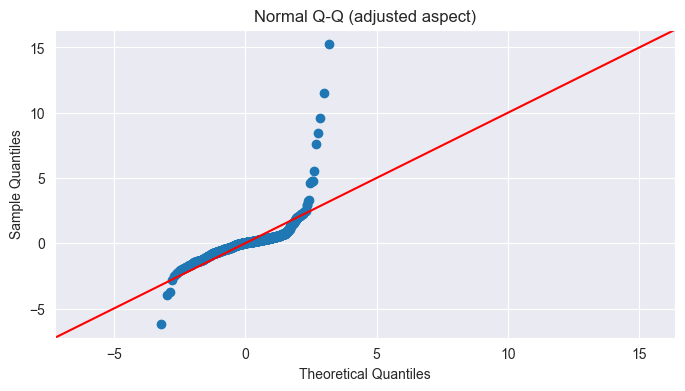

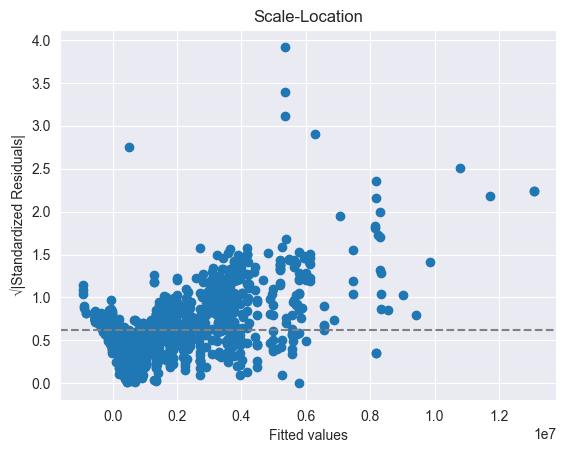

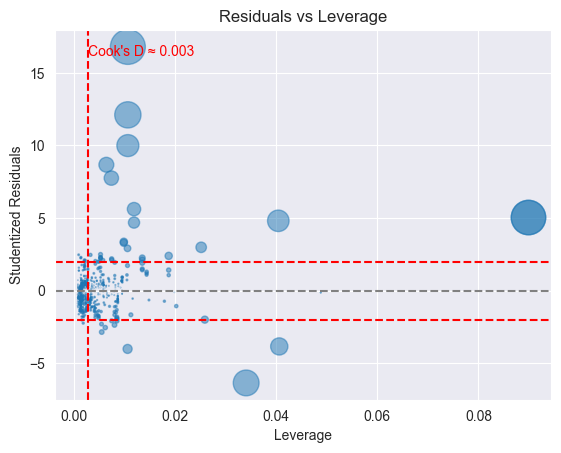

In [29]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
# Residuals vs Fitted
plt.scatter(lm2.fittedvalues, lm2.resid)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()
# Normal Q-Q (širi graf da linija deluje blaže)
sm.qqplot(lm2.resid, line='45', fit=True)
plt.gcf().set_size_inches(8, 4)
plt.title("Normal Q-Q (adjusted aspect)")
plt.show()
# Scale-Location
influence = lm2.get_influence()
std_resid = influence.resid_studentized_internal
abs_sqrt_resid = np.sqrt(np.abs(std_resid))
plt.scatter(lm2.fittedvalues, abs_sqrt_resid)
plt.axhline(np.mean(abs_sqrt_resid), color='gray', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("√|Standardized Residuals|")
plt.title("Scale-Location")
plt.show()
# Residuals vs Leverage + Cook's D threshold
leverage = influence.hat_matrix_diag
stud_resid = influence.resid_studentized_external
cooks_d = influence.cooks_distance[0]
n = len(lm2.model.endog)
thresh = 4 / n

plt.scatter(leverage, stud_resid, s=1000 * cooks_d, alpha=0.5)
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.axvline(thresh, color='red', linestyle='--')
plt.text(thresh, plt.ylim()[1]*0.9, f"Cook's D ≈ {thresh:.3f}", color='red')
plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")
plt.title("Residuals vs Leverage")
plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1794 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Price               1794 non-null   int64  
 1   Year                1794 non-null   float64
 2   Kilometer           1794 non-null   int64  
 3   Engine              1794 non-null   int64  
 4   Max.Power           1794 non-null   int64  
 5   Max.Torque          1794 non-null   int64  
 6   Length              1794 non-null   float64
 7   Width               1794 non-null   int64  
 8   Seating.Capacity    1794 non-null   int64  
 9   Fuel.Tank.Capacity  1794 non-null   float64
dtypes: float64(3), int64(7)
memory usage: 154.2 KB


In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import statsmodels.api as sm
import pandas as pd


X = sm.add_constant(df_train.drop(columns=['Price','Year','Kilometer','Max.Torque','Length','Width','Seating.Capacity']))

# √VIF iznad 2 - potencijalna kolinearnost (prag po izboru)


print("√VIF sa svim prediktorima:")
print((pd.Series([vif(X.values, i) for i in range(X.shape[1])],
                 index=X.columns) ** 0.5).sort_values(ascending=False))



√VIF sa svim prediktorima:
const                 3.809525
Engine                2.170241
Max.Power             2.135397
Fuel.Tank.Capacity    1.766220
dtype: float64


In [32]:
# Ponovno računanje VIF nakon izbacivanja 'tax'
X_no_tax = sm.add_constant(df_train.drop(columns=['Price','Year','Kilometer','Max.Torque','Length','Width','Seating.Capacity','Engine']))
# Ponovo računamo √VIF
print((pd.Series([vif(X_no_tax.values, i) for i in range(X_no_tax.shape[1])],
                 index=X_no_tax.columns) ** 0.5).sort_values(ascending=False))

const                 3.729317
Max.Power             1.640925
Fuel.Tank.Capacity    1.640925
dtype: float64


In [33]:
# hadje da probamo bez engine
import statsmodels.formula.api as smf  # izbacujemo u novom modelu ovu torque kolonu
lm3 = smf.ols('Price~ Q("Max.Power") + Q("Fuel.Tank.Capacity") ', data=df_train)
lm3 = lm3.fit()
lm3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     1105.
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          4.87e-291
Time:                        17:14:54   Log-Likelihood:                -22421.
No. Observations:                1435   AIC:                         4.485e+04
Df Residuals:                    1432   BIC:                         4.486e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -2.167e+06   1.46e+05    -14.886      0.000   -2.45e+06   -1.88e+06
Q("Max.Power")           2.955e+04   1048.039     28.198      0.000    2.75e+04    3.16e+04
Q("Fuel.Tank.Capacity")  2411.6206   4229.912      0.570      0.569   -5885.868    1.07e+04
==============================================================================
Omnibus:                     1512.512   Durbin-Watson:                   1.939
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           215559.202
Skew:                           4.781   Prob(JB):                         0.00
Kurtosis:                      62.277   Cond. No.                         564.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
import statsmodels.formula.api as smf

lm4 = smf.ols('Price~ Q("Max.Power") + Engine + Q("Fuel.Tank.Capacity") +Length', data=df_train)
lm4 = lm4.fit()
lm4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     598.4
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          1.81e-303
Time:                        17:14:54   Log-Likelihood:                -22386.
No. Observations:                1435   AIC:                         4.478e+04
Df Residuals:                    1430   BIC:                         4.481e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2.834e+05   5.85e+05      0.484      0.628   -8.64e+05    1.43e+06
Q("Max.Power")           3.777e+04   1403.329     26.914      0.000     3.5e+04    4.05e+04
Engine                   -915.5429    137.210     -6.673      0.000   -1184.698    -646.387
Q("Fuel.Tank.Capacity")  2.232e+04   4829.155      4.622      0.000    1.28e+04    3.18e+04
Length                   -704.3532    179.372     -3.927      0.000   -1056.214    -352.492
==============================================================================
Omnibus:                     1564.133   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           249874.539
Skew:                           5.036   Prob(JB):                         0.00
Kurtosis:                      66.856   Cond. No.                     7.11e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.11e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

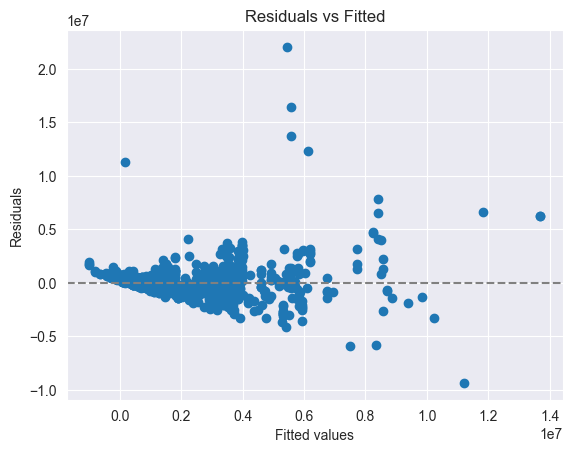

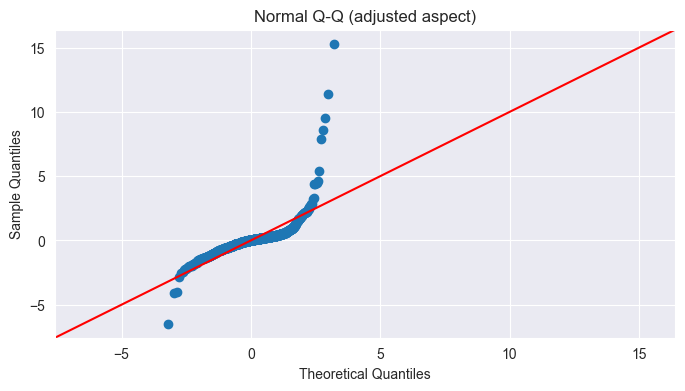

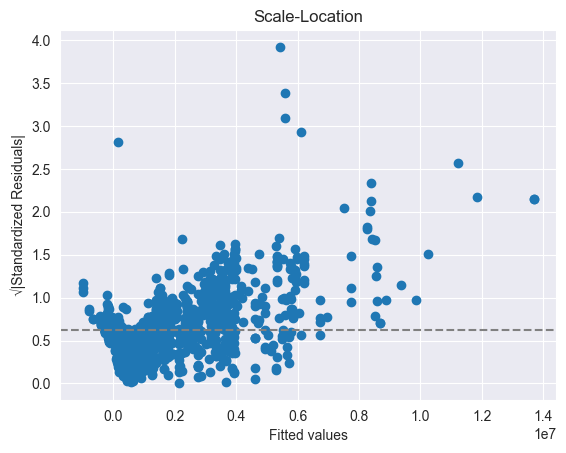

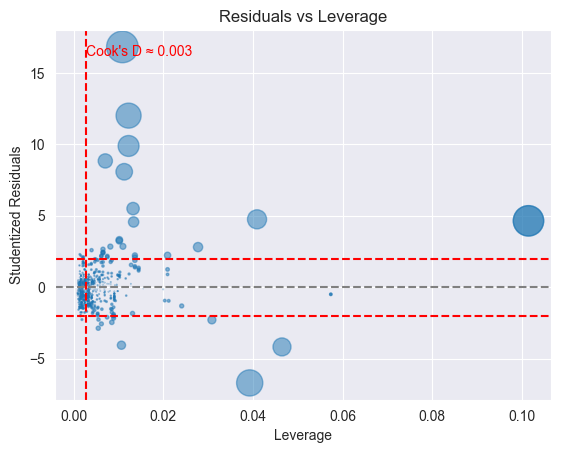

In [35]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
# Residuals vs Fitted
plt.scatter(lm4.fittedvalues, lm4.resid)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()
# Normal Q-Q (širi graf da linija deluje blaže)
sm.qqplot(lm4.resid, line='45', fit=True)
plt.gcf().set_size_inches(8, 4)
plt.title("Normal Q-Q (adjusted aspect)")
plt.show()
# Scale-Location
influence = lm4.get_influence()
std_resid = influence.resid_studentized_internal
abs_sqrt_resid = np.sqrt(np.abs(std_resid))
plt.scatter(lm4.fittedvalues, abs_sqrt_resid)
plt.axhline(np.mean(abs_sqrt_resid), color='gray', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("√|Standardized Residuals|")
plt.title("Scale-Location")
plt.show()
# Residuals vs Leverage + Cook's D threshold
leverage = influence.hat_matrix_diag
stud_resid = influence.resid_studentized_external
cooks_d = influence.cooks_distance[0]
n = len(lm4.model.endog)
thresh = 4 / n

plt.scatter(leverage, stud_resid, s=1000 * cooks_d, alpha=0.5)
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.axvline(thresh, color='red', linestyle='--')
plt.text(thresh, plt.ylim()[1]*0.9, f"Cook's D ≈ {thresh:.3f}", color='red')
plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")
plt.title("Residuals vs Leverage")
plt.show()